## LangGraph Terms

---

### **State**

*Think of state as your agent’s brain — where it remembers what happened at every step.*
It stores inputs, outputs, decisions, and memory during the workflow.

---

### **Node**

*Think of a node as a task performer — it does one job, like calling an LLM, using a tool, or doing a calculation.*
It takes the state as input, does something, and returns the updated state.

---

### **Edge**

*Think of edges as arrows showing the path between steps — they tell LangGraph what comes next.*
You can have simple arrows or logic-based ones like “if this, then go there.”

---

### **Graph**

*Think of the graph as the roadmap of your app — it connects all nodes and shows the flow of logic.*
It can go forward, loop, or branch like a mind map.

---

### **Agent**

*Think of an agent as a smart team member — it can think (LLM), use tools, and has its own memory.*
LangGraph lets multiple agents work together on a shared task.

---

### **Conditional Edge**

*Think of it like an if-else decision — based on the state, it chooses where to go next.*
Example: If LLM is unsure → ask another agent, else → finish.

---

### **Loop**

*Think of a loop as “try again until it works” — it repeats a node until a condition is met.*
Good for re-asking questions or retrying when LLM gets it wrong.

---

### **Tool**

*Think of a tool as something the agent can use — like Google Search, a calculator, or an API.*
It’s an external function the agent can call to fetch or process info.

---

### **Entry Point**

*Think of it as the starting gate — the first node that runs when you start the graph.*

---

### **Finish Point**

*Think of it as the final stop — the last node that completes the workflow and returns the final result.*

---

### **LangChain**

*Think of LangChain as the toolbox — LangGraph uses LangChain’s tools, LLMs, memory, and chains inside its nodes.*

## Use Case: Multi-Agent GitHub Project Recommender

---

### System Overview

* **User Input**: Keywords like "chatbot", "sentiment analysis", etc.
* **Search Agent**: Uses Tavily or a tool to fetch GitHub links related to the keyword.
* **Filter Agent**: Uses Gemini to filter useful projects.
* **Summarizer Agent**: Uses Gemini to summarize & recommend top ones.

---

### Step 1: Install Dependencies

In [15]:
!pip install langgraph langchain tavily-python langchain-google-genai langchain-community

### Step 3: Build Agent

In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from google.colab import userdata
from langchain_community.tools.tavily_search import TavilySearchResults

In [17]:
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')
if not GOOGLE_API_KEY:
  raise ValueError("Please set your GOOGLE_API_KEY in Colab Secrets")

In [18]:
# Choose a model that supports chat, e.g., 'gemini-1.5-flash-latest' or 'gemini-1.5-pro-latest' or 'models/gemma-4-31b-it'
llm = ChatGoogleGenerativeAI(model="models/gemma-4-31b-it", google_api_key=GOOGLE_API_KEY)

In [19]:
search = TavilySearchResults(max_results=5,tavily_api_key = TAVILY_API_KEY)

In [20]:
# Node 1: Search GitHub Repos via Tavily
def search_agent(state):
    keyword = state['keyword']
    results = search.run(f"site:github.com {keyword} project repo")
    state['raw_results'] = results
    return state

In [21]:
# Node 2: Filter GitHub links using Gemini
def filter_agent(state):
    raw = state['raw_results']
    raw_text = "\n".join([r["title"] + ": " + r["url"] for r in raw])
    prompt = f"""Here are some GitHub repo search results for '{state['keyword']}'.
    Please select and list only the most relevant repos:

    {raw_text}
    """
    filtered = llm.invoke(prompt)
    state['filtered_results'] = filtered.content
    return state

In [22]:
# Node 3: Summarize and Recommend
def summary_agent(state):
    prompt = f"""You are a GitHub assistant. Based on these filtered results, write a brief, clear recommendation to the user:
    {state['filtered_results']}
    """
    summary = llm.invoke(prompt)

    # OUTPUT PARSING: Format both thinking and final text line-by-line
    content = summary.content
    formatted_output = ""

    if isinstance(content, list):
        for block in content:
            # 1. Format the internal thinking process
            if block.get('type') == 'thinking':
                formatted_output += "**Agent Thinking Process:**\n"
                # Split the raw string by newlines to ensure line-by-line rendering
                thinking_lines = block.get('thinking', '').split('\n')
                for line in thinking_lines:
                    # Strip empty lines to keep it clean, add a blockquote style
                    if line.strip():
                        formatted_output += f"> {line.strip()}\n"
                formatted_output += "\n---\n\n"

            # 2. Format the final output
            elif block.get('type') == 'text':
                formatted_output += "**Final Recommendation:**\n"
                formatted_output += block.get('text', '') + "\n"
    else:
        # Fallback just in case the model returns a plain string
        formatted_output = str(content)

    state['recommendation'] = formatted_output
    return state

In [23]:
# LangGraph flow
builder = StateGraph(dict)
builder.add_node("search", search_agent)
builder.add_node("filter", filter_agent)
builder.add_node("summarize", summary_agent)

In [24]:
builder.set_entry_point("search")
builder.add_edge("search", "filter")
builder.add_edge("filter", "summarize")
builder.add_edge("summarize", END)

In [25]:
app = builder.compile()

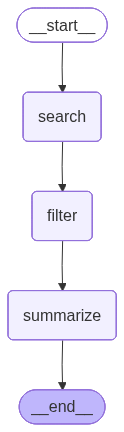

In [26]:
from IPython.display import Image, display

# Generate and display the graph visualization
display(Image(app.get_graph().draw_mermaid_png()))

### Step 4: Run It

In [27]:
if __name__ == "__main__":
    query = input("Enter keyword(s) to find GitHub projects: ")
    result = app.invoke({"keyword": query})
    print("\nGemini Recommendation:")
    print(result['recommendation'])

Enter keyword(s) to find GitHub projects: Agentic AI

Gemini Recommendation:
**Agent Thinking Process:**
> GitHub assistant.
> A list of filtered results (which contains a "thinking" block and a "text" block).
> Write a brief, clear recommendation to the user based on these results.
> *   The input is essentially a log of a previous processing step.
> *   The "thinking" block analyzes five results.
> *   The "text" block summarizes the top three recommendations:
> 1.  `ProjectProRepo/Agentic-AI` (Resource hub/tutorials).
> 2.  `panaversity/learn-agentic-ai` (Technical guide/DACA pattern/Kubernetes).
> 3.  `ed-donner/agents` (Agentic AI Engineering).
> *   The user wants a "brief, clear recommendation."
> *   I should present these three repositories in a way that helps the user choose based on their needs (e.g., general learning vs. technical implementation vs. engineering).

---

**Final Recommendation:**
Based on the search results, here are the best repositories for exploring Agenti

### Agents

| Agent Name      | Purpose                                       |
| --------------- | --------------------------------------------- |
| `search_agent`  | Fetch GitHub links from search engine         |
| `filter_agent`  | Use Gemini LLM to pick relevant repos         |
| `summary_agent` | Use Gemini LLM to write user-friendly summary |